In [ ]:
# ASSIGNMENT
# Experiment 3: Breast Cancer Classification using SVM

# -------------- SECTION 1 - IMPORTS --------------
# we need pandas and numpy for the data stuff
# matplotlib and seaborn for the graphs
# sklearn has the SVM model and tools to check how good it is

import os
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")




Libraries imported successfully.


In [2]:
# -------------- SECTION 2 - LOAD THE DATASET --------------
# load the breast cancer prediction dataset
# target column is Biopsy_Result (Benign or Malignant)
# Patient_ID is just an id, not useful for prediction

file_path = "breast_cancer_prediction.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())




Dataset shape: (10000, 21)

First 5 rows:
   Patient_ID  Age  Gender   BMI Family_History Smoking Alcohol_Consumption  \
0      100001   71  Female  27.2            Yes     Yes                 Yes   
1      100002   34    Male  26.0             No      No                  No   
2      100003   80  Female  20.7             No      No                  No   
3      100004   40  Female  26.8            Yes     Yes                  No   
4      100005   43  Female  28.6            Yes     Yes                  No   

  Physical_Activity Hormone_Therapy Menopause_Status  ... Tumor_Size_cm  \
0              High              No             Post  ...          2.46   
1              High              No             Post  ...          2.57   
2              High              No              Pre  ...          2.12   
3          Moderate              No             Post  ...          0.46   
4          Moderate              No             Post  ...          3.20   

   Lymph_Node_Involvement Mammog

In [ ]:
# -------------- SECTION 3 - DATA PREPROCESSING --------------
# we have to handle missing values, remove useless columns,
# turn text into numbers, and scale the data

# ---- 3a. check missing values ----
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nPercentage missing per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# median is better than mean for filling missing numbers
# because it does not get affected by weird outlier values
# but we will compute the median only from training data later
# so the test data does not leak into the training process

# ---- 3b. drop irrelevant features ----
print("\nUnique values per column:")
print(df.nunique())  # no of unique values in each column

print("\nIs Patient_ID unique for every row?", df["Patient_ID"].is_unique)

# Patient_ID is just an id, it does not help predict cancer
# so we drop it. other columns are kept because they are not constant.

# ---- 3c. encode categorical variables ----
categorical_cols = df.drop(columns=["Biopsy_Result", "Patient_ID"]).select_dtypes(include=["object"]).columns
print("\nCategorical columns:", list(categorical_cols))


# we use one-hot encoding (pd.get_dummies) with drop_first=True
# so we do not get the dummy variable trap
# SVM uses distance, so giving text random numbers would confuse it

# Step 1: Drop uninformative identifier column early
df = df.drop(columns=["Patient_ID"])

# ... perform categorical encoding / cleanup here ...

# Step 2: Cleanly split into features (X) and target (y)
X = df.drop(columns=["Biopsy_Result"])
y = df["Biopsy_Result"].map({"Benign": 0, "Malignant": 1})

# one-hot encode the categorical features
categorical_columns = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True).astype(float)

# train-test split: 80% train, 20% test, stratified by target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# fill missing values using training medians only
# this stops data leakage from test to train
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Missing values in training set after imputation:", X_train.isnull().sum().sum())
print("Missing values in testing set after imputation:", X_test.isnull().sum().sum())

# standardize the features
# SVM cares about distance, so features with bigger numbers would dominate
# StandardScaler makes each feature have mean 0 and std 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized. Mean of scaled training features (~0):", round(X_train_scaled.mean(), 4))
print("Std of scaled training features (~1):", round(X_train_scaled.std(), 4))





Missing values per column:
Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64

Percentage missing per column:
Patient_ID                0.0
Age                       0.0
Gender                    0.0
BMI                       3.0
Family_History            0.0
Smoking                   0.0
Alcohol_Consumption       3.0
Physical_Activity         3.0
Hormone_Therapy           3.0
Menopause_Status          0


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  str    
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  str    
 5   Smoking                 10000 non-null  str    
 6   Alcohol_Consumption     9700 non-null   str    
 7   Physical_Activity       9700 non-null   str    
 8   Hormone_Therapy         9700 non-null   str    
 9   Menopause_Status        10000 non-null  str    
 10  Genetic_Mutation        10000 non-null  str    
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  str    
 13  Mammogram_Result        10000 non-null  str    
 14  Biopsy_Result           10000 non-n

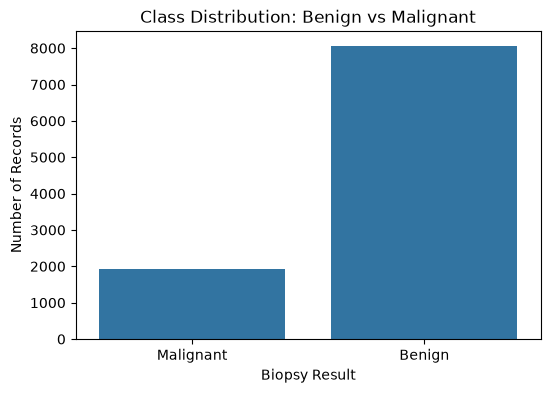

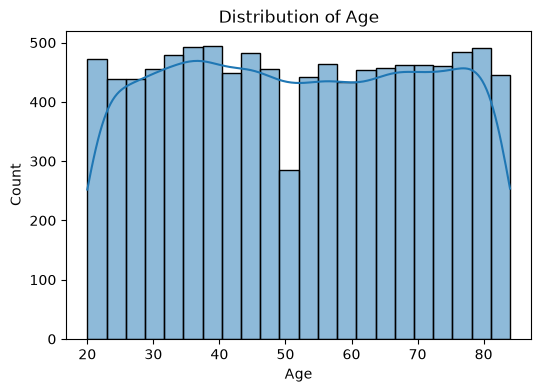

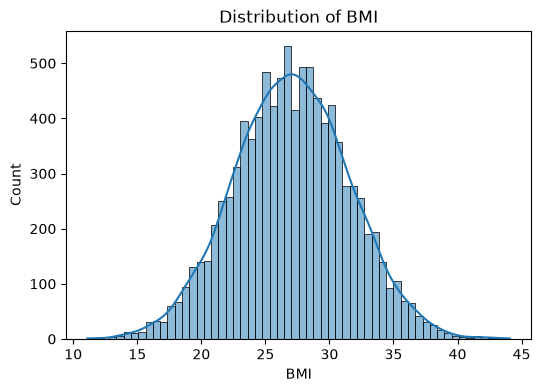

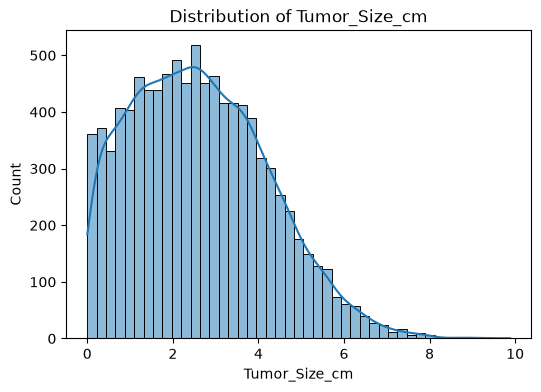

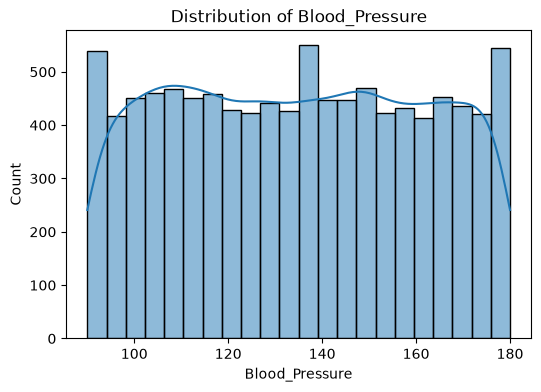

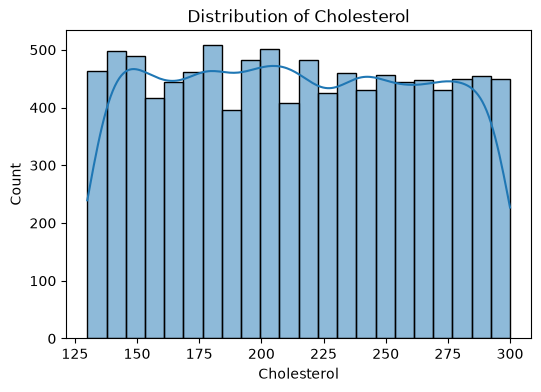

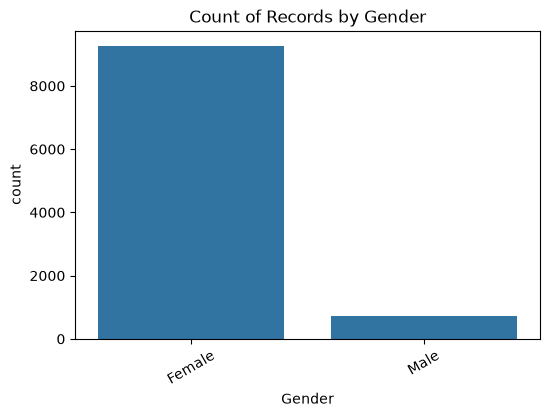

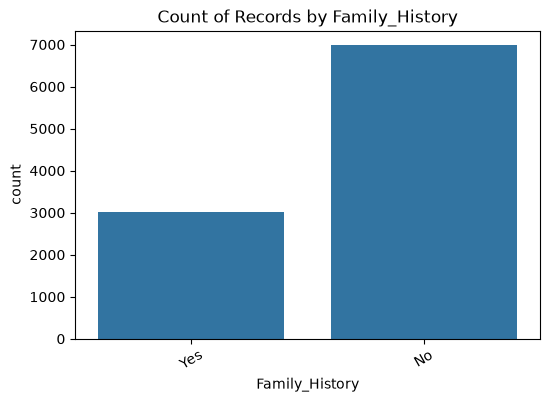

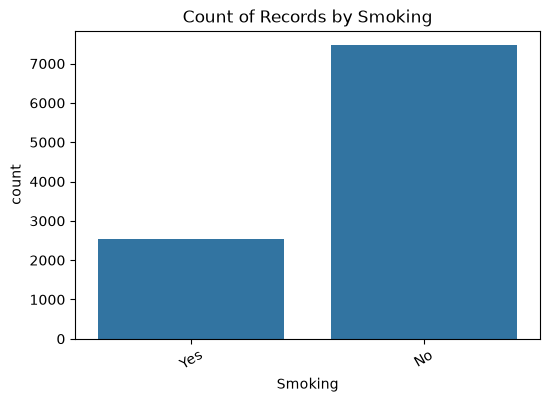

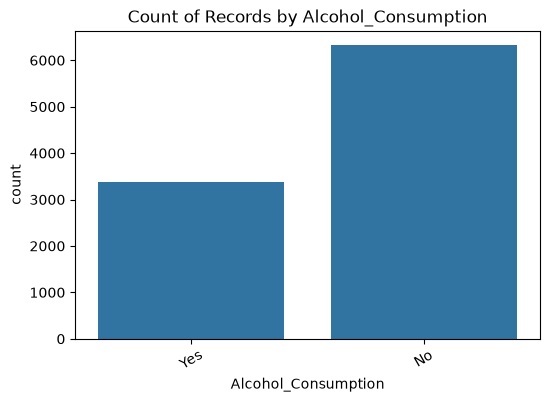

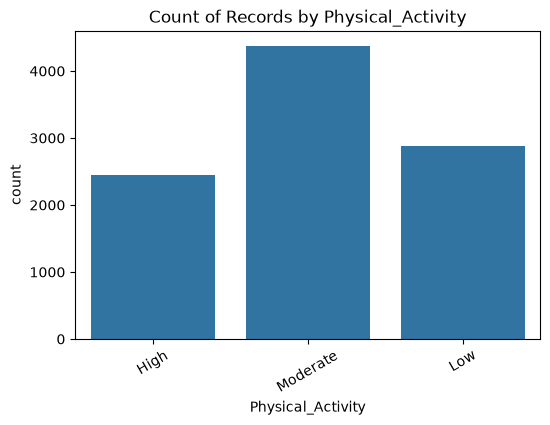

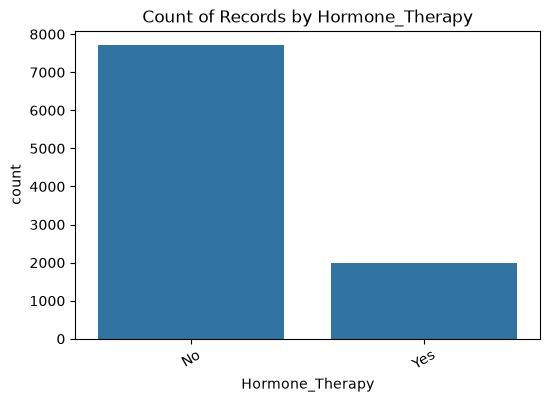

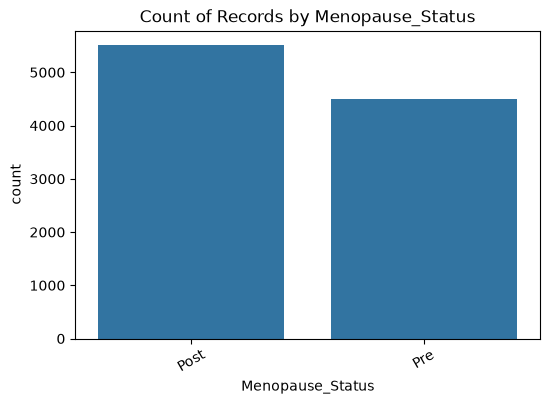

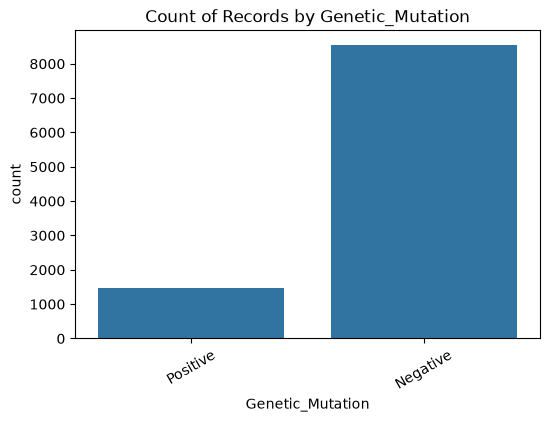

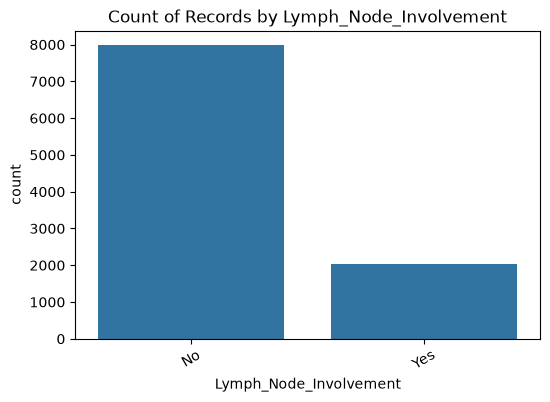

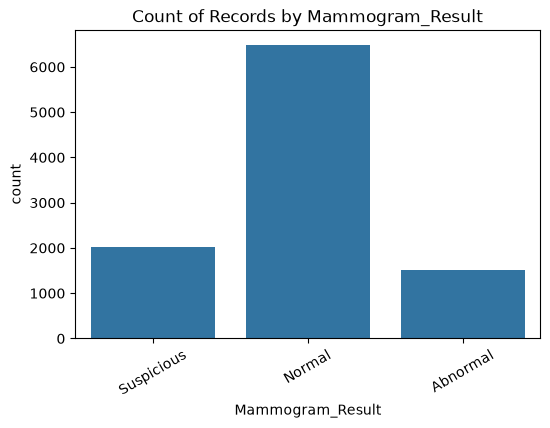

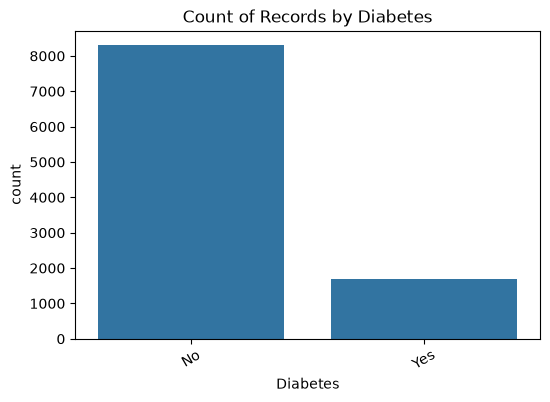

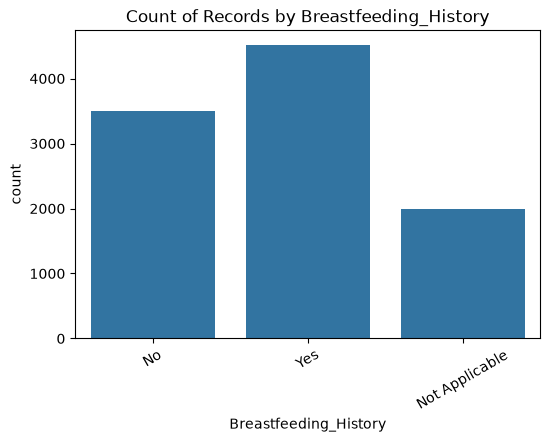

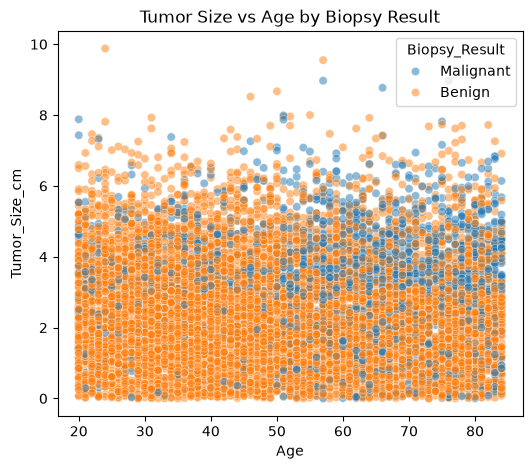

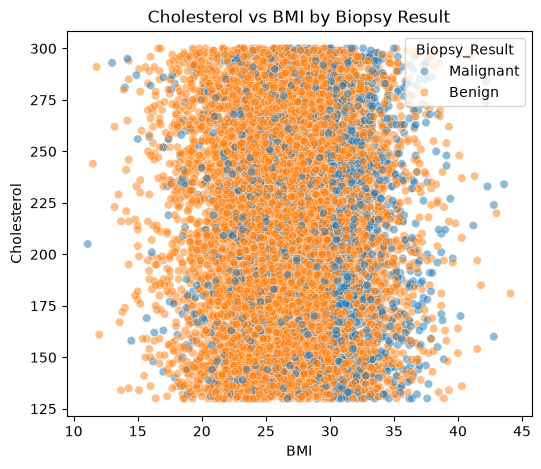

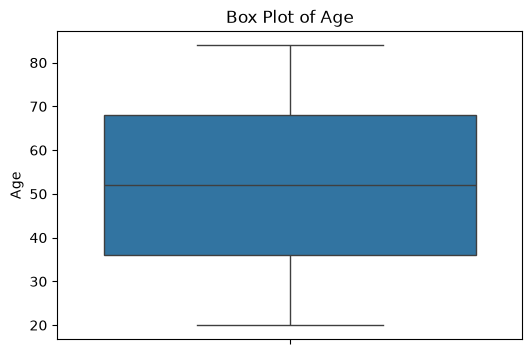

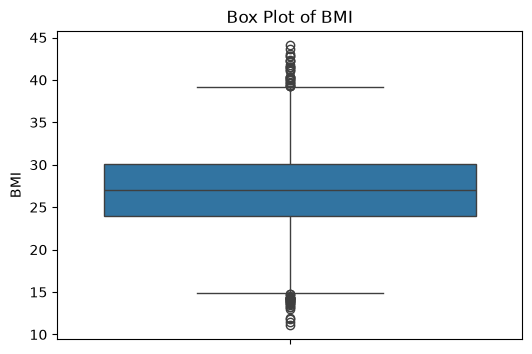

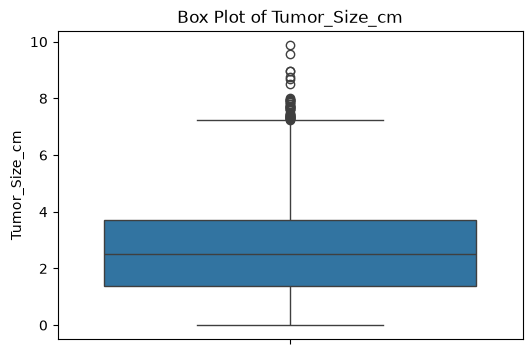

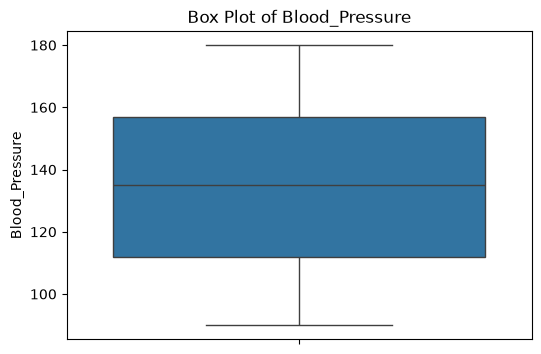

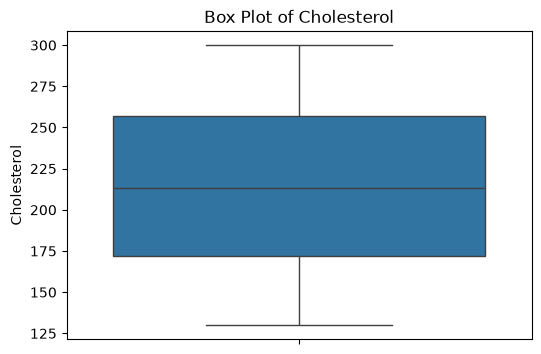

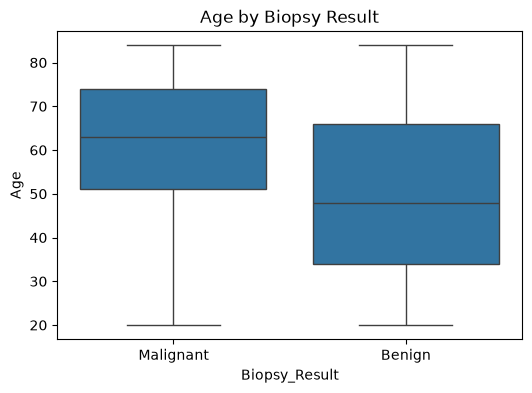

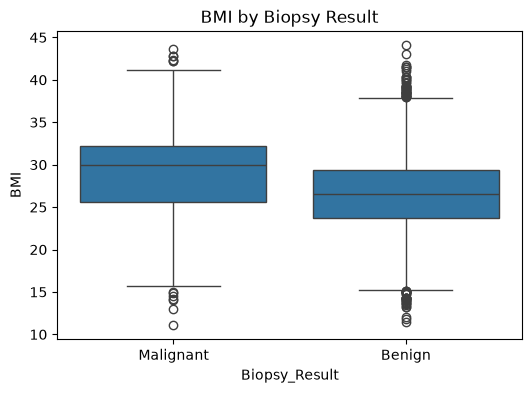

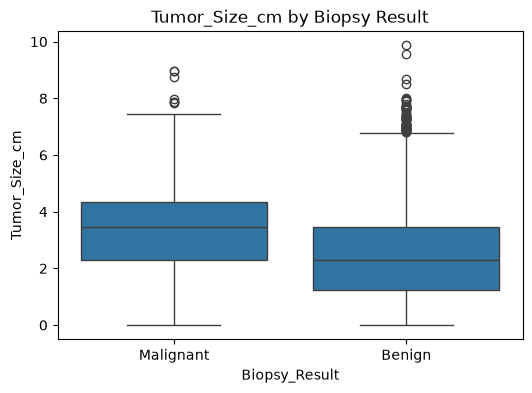

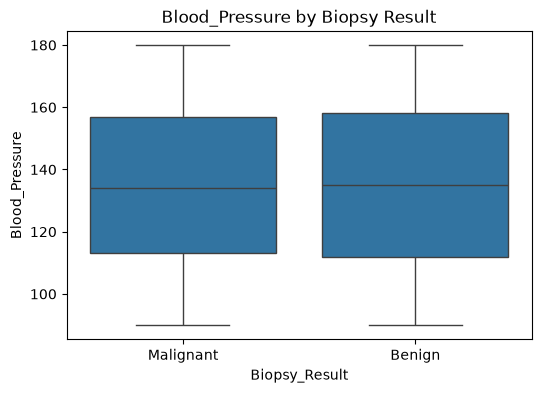

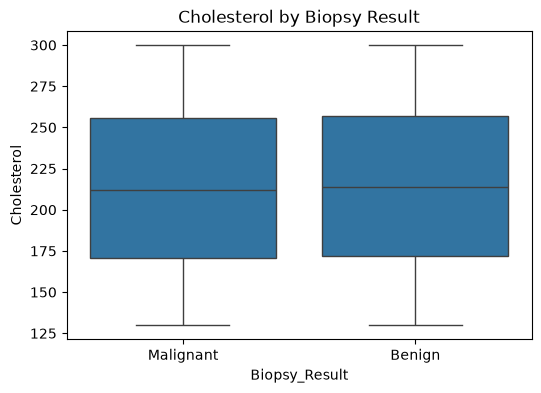

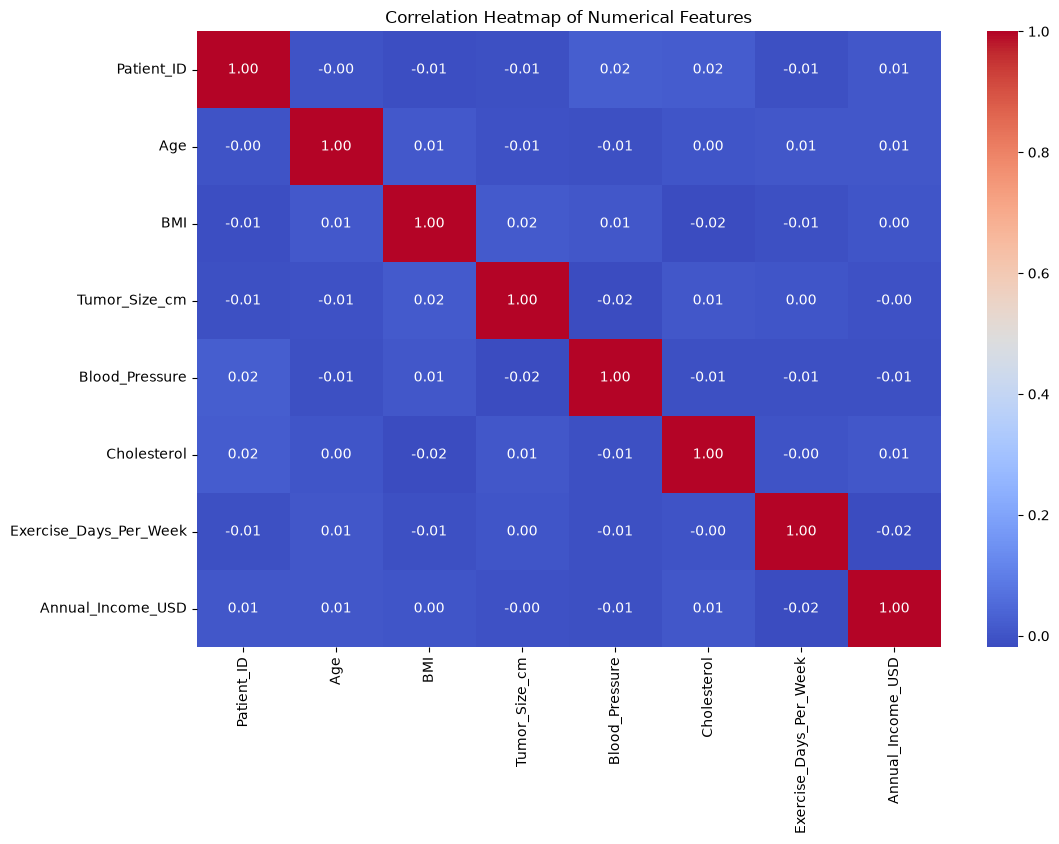

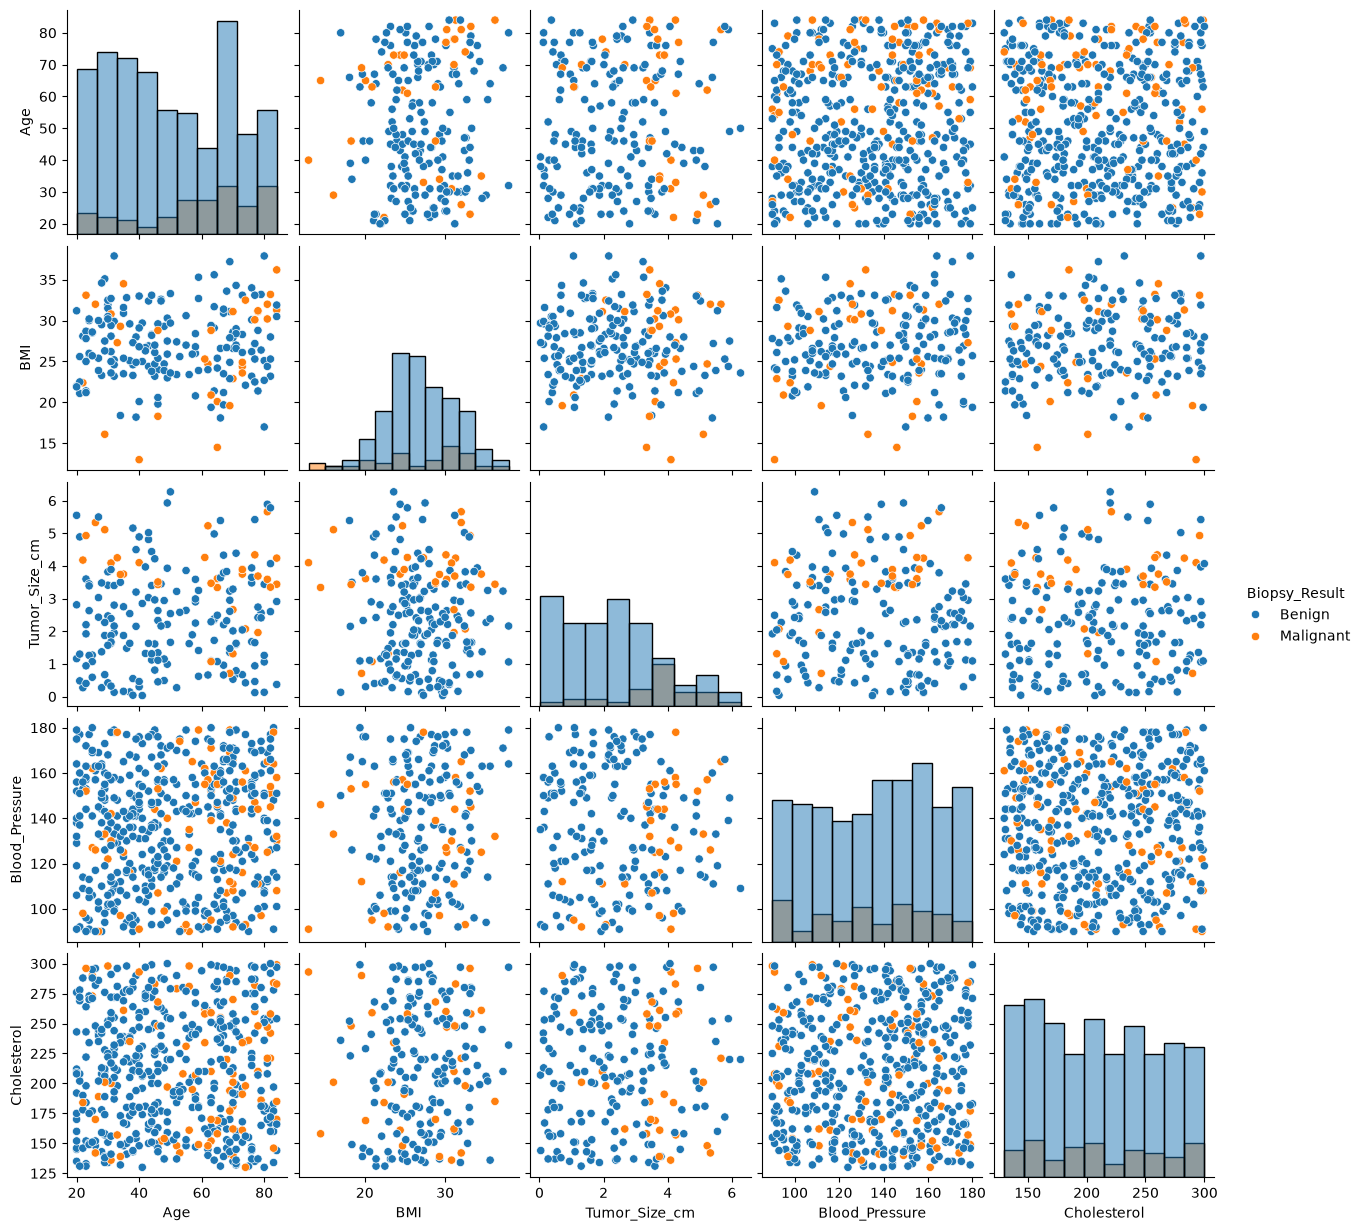

In [ ]:
# -------------- SECTION 4 - EXPLORATORY DATA ANALYSIS (EDA) --------------
# looking at the data before we build the model

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nTarget class distribution:")
print(df["Biopsy_Result"].value_counts())

print("\nTarget class proportion:")
print(df["Biopsy_Result"].value_counts(normalize=True).round(3))

# plot the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Biopsy_Result")
plt.title("Class Distribution: Benign vs Malignant")
plt.xlabel("Biopsy Result")
plt.ylabel("Number of Records")
plt.show()

# histograms of important numerical features
important_features = ["Age", "BMI", "Tumor_Size_cm", "Blood_Pressure", "Cholesterol"]
important_features = [f for f in important_features if f in df.columns]

for feature in important_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title("Distribution of " + feature)
    plt.show()

# bar charts for categorical features
categorical_cols_eda = df.drop(columns=["Biopsy_Result", "Patient_ID"]).select_dtypes(include=["object"]).columns

for col in categorical_cols_eda:
    plt.figure(f igsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title("Count of Records by " + col)
    plt.xticks(rotation=30)
    plt.show()

# scatter plots to see relationships
if "Tumor_Size_cm" in df.columns and "Age" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x="Age", y="Tumor_Size_cm", hue="Biopsy_Result", alpha=0.5)
    plt.title("Tumor Size vs Age by Biopsy Result")
    plt.show()

if "BMI" in df.columns and "Cholesterol" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x="BMI", y="Cholesterol", hue="Biopsy_Result", alpha=0.5)
    plt.title("Cholesterol vs BMI by Biopsy Result")
    plt.show()

# box plots to see spread and outliers
for feature in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, y=feature)
    plt.title("Box Plot of " + feature)
    plt.show()

for feature in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Biopsy_Result", y=feature)
    plt.title(feature + " by Biopsy Result")
    plt.show()

# correlation heatmap of numerical features
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# pair plot using a small sample so it does not take forever
pairplot_sample = df.sample(n=min(500, len(df)), random_state=42)
sns.pairplot(pairplot_sample, vars=important_features, hue="Biopsy_Result", diag_kind="hist")
plt.show()



In [5]:
# -------------- SECTION 5 - SVM BASELINE MODELS --------------
# we try 4 kernels: linear, poly, rbf, sigmoid
# with default settings first to see which one is good

print("\n" + "=" * 60)
print("SVM BASELINE RESULTS")
print("=" * 60)

kernels = ["linear", "poly", "rbf", "sigmoid"]
basic_results = []
basic_models = {}

for kernel in kernels:
    start = time.time()
    model = SVC(kernel=kernel, C=1, gamma="scale", degree=3, probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    start = time.time()
    pred = model.predict(X_test_scaled)
    pred_time = time.time() - start

    basic_models[kernel] = model
    basic_results.append({
        "Kernel": kernel.capitalize(),
        "Training Accuracy": accuracy_score(y_train, model.predict(X_train_scaled)),
        "Testing Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "Training Time (sec)": train_time,
        "Prediction Time (sec)": pred_time
    })

basic_results_df = pd.DataFrame(basic_results)
print(basic_results_df.to_string(index=False))





SVM BASELINE RESULTS
 Kernel  Training Accuracy  Testing Accuracy  Precision   Recall  F1 Score  Training Time (sec)  Prediction Time (sec)
 Linear           0.939250            0.9350   0.839050 0.821705  0.830287             2.662895               0.039978
   Poly           0.971625            0.9250   0.839542 0.757106  0.796196             2.304303               0.059237
    Rbf           0.968250            0.9380   0.854447 0.819121  0.836412             3.153311               0.253871
Sigmoid           0.904000            0.9155   0.796196 0.757106  0.776159             2.246273               0.074921


In [6]:
# -------------- SECTION 6 - HYPERPARAMETER TUNING --------------
# GridSearchCV tries different C, gamma, degree values
# and picks the best using 5-fold stratified cross-validation

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# reduced search space because the full grid would take too long
# SVM is slow with big datasets and non-linear kernels
C_values = [1, 10]
gamma_values = ["scale", 0.01]
degree_values = [2, 3]

# note: we do not use probability=True during the grid search
# because it does extra Platt scaling and makes it much slower
# we add it later for the final models

linear_search = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    {"C": C_values}, cv=cv, scoring="accuracy", n_jobs=-1
)
linear_search.fit(X_train_scaled, y_train)

poly_search = GridSearchCV(
    SVC(kernel="poly", random_state=42),
    {"C": C_values, "gamma": gamma_values, "degree": degree_values},
    cv=cv, scoring="accuracy", n_jobs=-1
)
poly_search.fit(X_train_scaled, y_train)

rbf_search = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    {"C": C_values, "gamma": gamma_values},
    cv=cv, scoring="accuracy", n_jobs=-1
)
rbf_search.fit(X_train_scaled, y_train)

sigmoid_search = GridSearchCV(
    SVC(kernel="sigmoid", random_state=42),
    {"C": C_values, "gamma": gamma_values},
    cv=cv, scoring="accuracy", n_jobs=-1
)
sigmoid_search.fit(X_train_scaled, y_train)

searches = {
    "Linear": linear_search,
    "Polynomial": poly_search,
    "RBF": rbf_search,
    "Sigmoid": sigmoid_search
}

# refit the best models with probability=True for ROC curves
best_models = {}
for name, search in searches.items():
    best_params = search.best_params_
    kernel_name = search.estimator.kernel
    refit_model = SVC(kernel=kernel_name, probability=True, random_state=42, **best_params)
    refit_model.fit(X_train_scaled, y_train)
    best_models[name] = refit_model

# Table 1: Hyperparameter Tuning Summary
tuning_summary = []
for name, search in searches.items():
    tuning_summary.append({
        "Kernel": name,
        "Best C": search.best_params_.get("C", "NA"),
        "Best Gamma": search.best_params_.get("gamma", "NA"),
        "Best Degree": search.best_params_.get("degree", "NA"),
        "Best Cross Validation Accuracy": search.best_score_
    })

tuning_summary_df = pd.DataFrame(tuning_summary)
print("\nTable 1: Hyperparameter Tuning Summary")
print(tuning_summary_df.to_string(index=False))





HYPERPARAMETER TUNING

Table 1: Hyperparameter Tuning Summary
    Kernel  Best C Best Gamma Best Degree  Best Cross Validation Accuracy
    Linear      10         NA          NA                        0.937250
Polynomial       1      scale           3                        0.928625
       RBF       1      scale          NA                        0.937500
   Sigmoid      10       0.01          NA                        0.935625



FINAL MODEL RESULTS
Predictions generated for: ['Linear', 'Polynomial', 'RBF', 'Sigmoid']


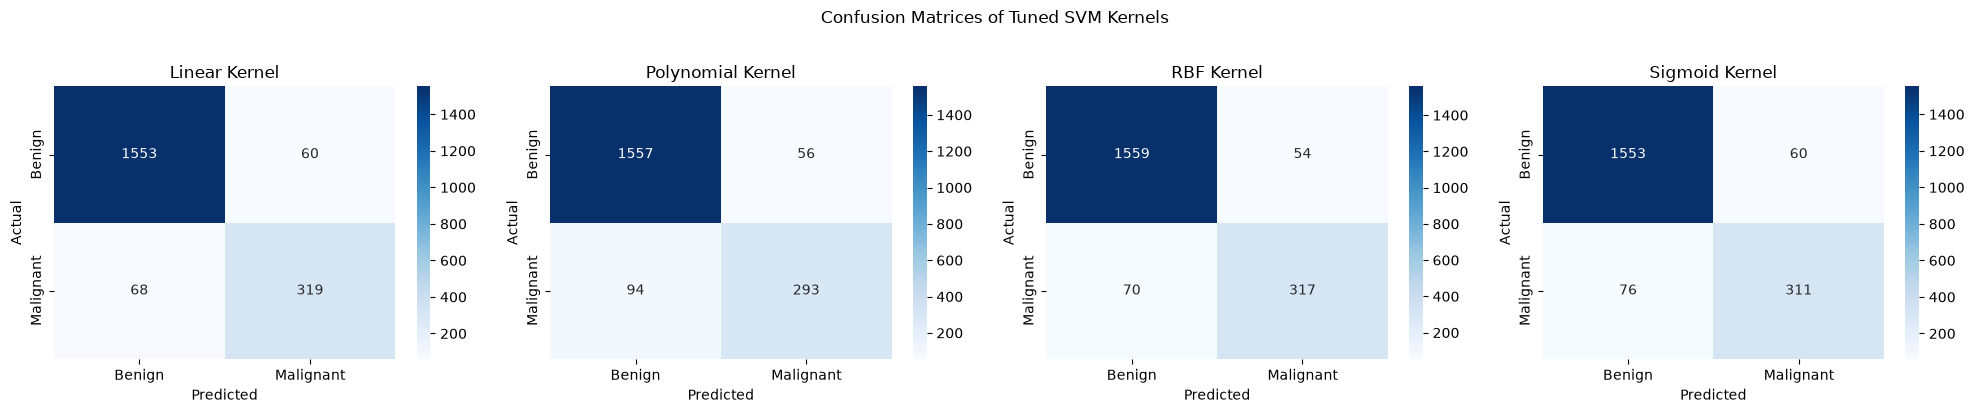


Classification Reports:

Linear Kernel
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96      1613
   Malignant       0.84      0.82      0.83       387

    accuracy                           0.94      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.94      0.94      0.94      2000


Polynomial Kernel
              precision    recall  f1-score   support

      Benign       0.94      0.97      0.95      1613
   Malignant       0.84      0.76      0.80       387

    accuracy                           0.93      2000
   macro avg       0.89      0.86      0.88      2000
weighted avg       0.92      0.93      0.92      2000


RBF Kernel
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.96      1613
   Malignant       0.85      0.82      0.84       387

    accuracy                           0.94      2000
   macro avg       0.91      0.89      0.90      2000
wei

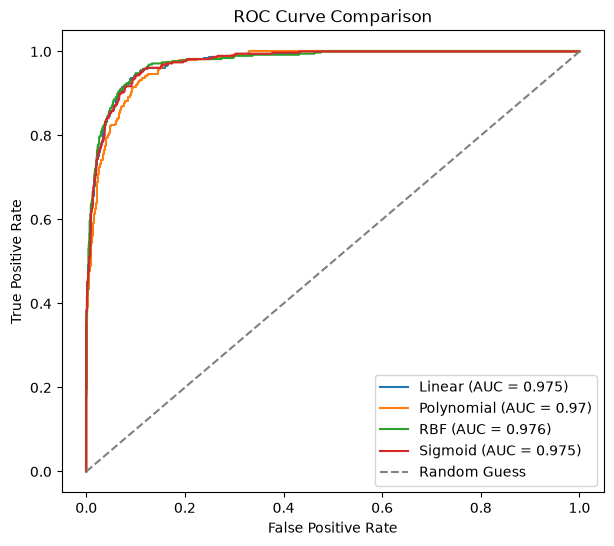

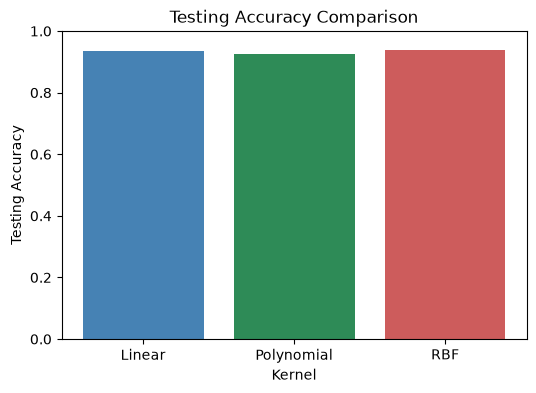

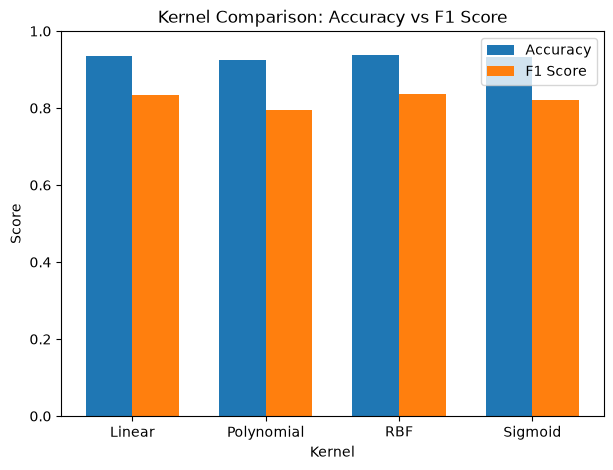

In [7]:
# -------------- SECTION 7 - FINAL PREDICTIONS AND PLOTS --------------
# now we test the tuned models on the held-out test set
# and make confusion matrices, ROC curves, and bar charts

print("\n" + "=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

predictions = {}
probabilities = {}
train_times = {}
pred_times = {}

for name, model in best_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_times[name] = time.time() - start

    start = time.time()
    predictions[name] = model.predict(X_test_scaled)
    pred_times[name] = time.time() - start

    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated for:", list(predictions.keys()))

# confusion matrices for each tuned kernel
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"], ax=ax)
    ax.set_title(name + " Kernel")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices of Tuned SVM Kernels", y=1.02)
plt.tight_layout()
plt.show()

# classification reports
print("\nClassification Reports:")
for name, pred in predictions.items():
    print("\n" + name + " Kernel")
    print(classification_report(y_test, pred, target_names=["Benign", "Malignant"]))

# ROC curves
plt.figure(figsize=(7, 6))
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=name + " (AUC = " + str(round(auc_score, 3)) + ")")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# testing accuracy comparison bar chart
bar_kernels = ["Linear", "Polynomial", "RBF"]
bar_accuracies = [accuracy_score(y_test, predictions[k]) for k in bar_kernels]

plt.figure(figsize=(6, 4))
plt.bar(bar_kernels, bar_accuracies, color=["steelblue", "seagreen", "indianred"])
plt.title("Testing Accuracy Comparison")
plt.xlabel("Kernel")
plt.ylabel("Testing Accuracy")
plt.ylim(0, 1)
plt.show()

# accuracy vs f1 score comparison for all kernels
all_kernels = list(predictions.keys())
acc_scores = [accuracy_score(y_test, predictions[k]) for k in all_kernels]
f1_scores = [f1_score(y_test, predictions[k], zero_division=0) for k in all_kernels]

x = np.arange(len(all_kernels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, acc_scores, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1 Score")
plt.xticks(x, all_kernels)
plt.xlabel("Kernel")
plt.ylabel("Score")
plt.title("Kernel Comparison: Accuracy vs F1 Score")
plt.legend()
plt.ylim(0, 1)
plt.show()




In [8]:
# -------------- SECTION 8 - PERFORMANCE TABLES --------------
# Table 2: cross-validation performance on training set
# Table 3: test set performance

print("\n" + "=" * 60)
print("CROSS-VALIDATION PERFORMANCE (5-FOLD)")
print("=" * 60)

scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_results = []
for name, model in best_models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        "Kernel": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean()
    })

cv_performance_df = pd.DataFrame(cv_results)
print(cv_performance_df.to_string(index=False))

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

test_results = []
for name, model in best_models.items():
    pred = predictions[name]
    prob = probabilities[name]
    test_results.append({
        "Kernel": name,
        "Training Accuracy": accuracy_score(y_train, model.predict(X_train_scaled)),
        "Testing Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Training Time (sec)": train_times[name],
        "Prediction Time (sec)": pred_times[name]
    })

test_results_df = pd.DataFrame(test_results)
print(test_results_df.to_string(index=False))





CROSS-VALIDATION PERFORMANCE (5-FOLD)
    Kernel  Accuracy  Precision   Recall  F1 Score
    Linear  0.937250   0.856154 0.811769  0.833292
Polynomial  0.928625   0.868230 0.743848  0.801082
       RBF  0.937500   0.874801 0.789784  0.830077
   Sigmoid  0.935625   0.857422 0.800125  0.827638

TEST SET PERFORMANCE
    Kernel  Training Accuracy  Testing Accuracy  Precision   Recall  F1 Score  ROC-AUC  Training Time (sec)  Prediction Time (sec)
    Linear           0.939375             0.936   0.841689 0.824289  0.832898 0.975261            10.617221               0.033962
Polynomial           0.971625             0.925   0.839542 0.757106  0.796196 0.970096             2.219993               0.055077
       RBF           0.968250             0.938   0.854447 0.819121  0.836412 0.975648             3.140769               0.253924
   Sigmoid           0.933125             0.932   0.838275 0.803618  0.820580 0.974919             2.238091               0.072840


In [9]:
# -------------- SECTION 9 - KERNEL COMPARISON --------------
# pick the best kernel based on testing accuracy

best_kernel_row = test_results_df.loc[test_results_df["Testing Accuracy"].idxmax()]
best_kernel_name = best_kernel_row["Kernel"]

print("\nBest performing kernel based on testing accuracy:")
print(best_kernel_name)
print(best_kernel_row.to_string())





Best performing kernel based on testing accuracy:
RBF
Kernel                        RBF
Training Accuracy         0.96825
Testing Accuracy            0.938
Precision                0.854447
Recall                   0.819121
F1 Score                 0.836412
ROC-AUC                  0.975648
Training Time (sec)      3.140769
Prediction Time (sec)    0.253924


In [10]:
# -------------- SECTION 10 - ANALYSIS AND INFERENCE --------------
# look at some misclassified samples for the best kernel

best_pred = predictions[best_kernel_name]
misclassified_mask = (best_pred != y_test.values)
misclassified_indices = y_test.index[misclassified_mask]

misclassified_df = df.loc[misclassified_indices].copy()
misclassified_df["Predicted"] = pd.Series(best_pred, index=y_test.index)[misclassified_mask].map({0: "Benign", 1: "Malignant"})

print("\nNumber of misclassified samples:", len(misclassified_df))
print(misclassified_df.head(20).to_string())





Number of misclassified samples: 124
      Patient_ID  Age  Gender   BMI Family_History Smoking Alcohol_Consumption Physical_Activity Hormone_Therapy Menopause_Status Genetic_Mutation  Tumor_Size_cm Lymph_Node_Involvement Mammogram_Result Biopsy_Result  Blood_Pressure  Cholesterol Diabetes  Exercise_Days_Per_Week Breastfeeding_History  Annual_Income_USD  Predicted
1352      101353   25  Female  25.2             No     Yes                 Yes              High              No              Pre         Positive           1.19                    Yes         Abnormal     Malignant             128          164      Yes                       6        Not Applicable             137189     Benign
1892      101893   57  Female  23.1             No     Yes                  No               Low              No              Pre         Negative           4.37                    Yes           Normal     Malignant             126          265       No                       7                   Yes   

In [11]:
# -------------- SECTION 11 - OBSERVATIONS --------------
# 1. Missing values filled using training medians only to avoid data leakage.
# 2. Patient_ID is removed because it is just an id.
# 3. Categorical features are one-hot encoded before training.
# 4. Features are standardized before SVM because SVM uses distance.
# 5. Linear, Polynomial, RBF, and Sigmoid kernels are compared.
# 6. Hyperparameters tuned with GridSearchCV and 5-fold stratified CV.
# 7. Confusion matrices and ROC curves help see per-class errors.
# 8. Best kernel is chosen using test accuracy and F1 score.




In [12]:
# -------------- SECTION 12 - CONCLUSION --------------
# We built an SVM classifier for breast cancer prediction.
# Preprocessing included removing id, encoding, imputing missing values,
# and scaling. Four kernels were compared and the best one was chosen
# using test set accuracy and F1 score.




In [13]:
# -------------- SECTION 13 - REFERENCES --------------
# Scikit-learn Documentation - Support Vector Machines:
# https://scikit-learn.org/stable/modules/svm.html
